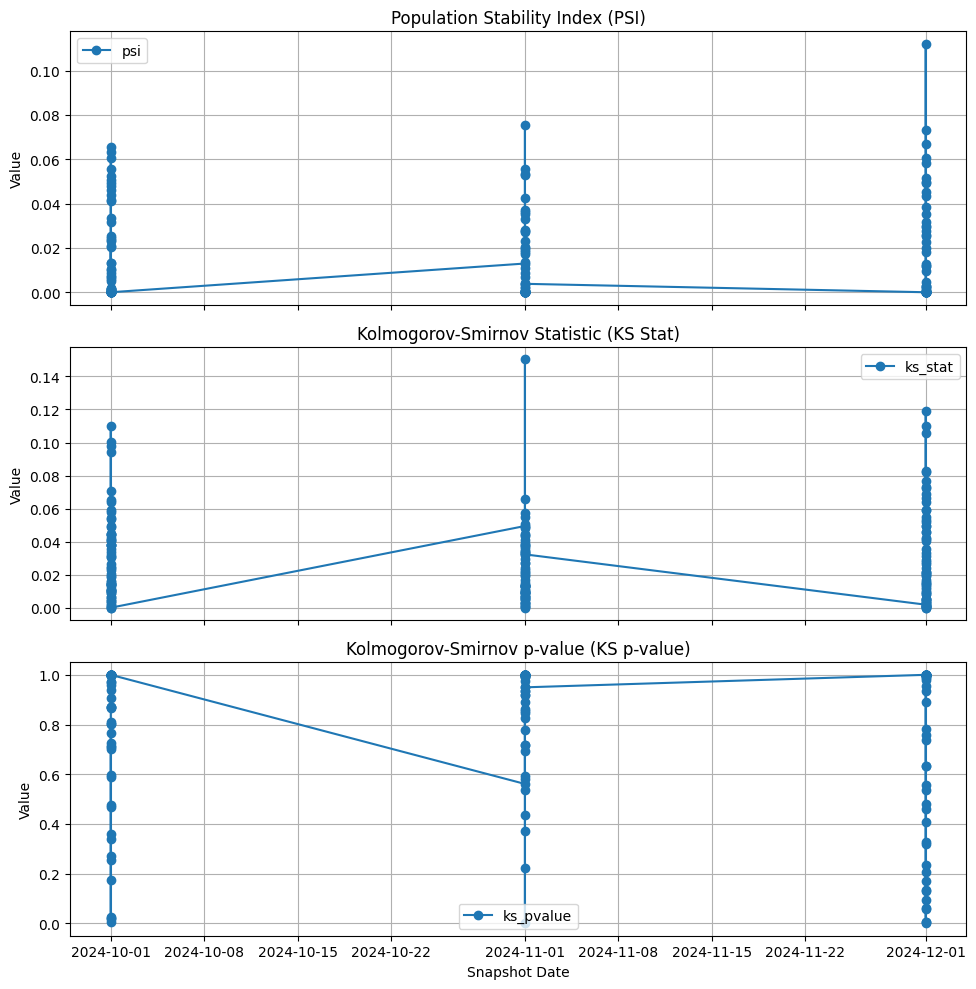

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import glob, os

# --- Load monitoring data ---
path = "datamart/gold/data_monitoring/*.parquet"
files = glob.glob(path)

dfs = []
for f in files:
    df = pd.read_parquet(f)
    date_part = "_".join(os.path.basename(f).split("_")[-3:]).split(".")[0]
    df["snapshot_date"] = pd.to_datetime(date_part, format="%Y_%m_%d")
    dfs.append(df)

monitor_df = pd.concat(dfs).sort_values("snapshot_date")

# --- Create figure with 3 subplots ---
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

metrics = ["psi", "ks_stat", "ks_pvalue"]
titles = [
    "Population Stability Index (PSI)",
    "Kolmogorov-Smirnov Statistic (KS Stat)",
    "Kolmogorov-Smirnov p-value (KS p-value)"
]

for ax, metric, title in zip(axes, metrics, titles):
    ax.plot(monitor_df["snapshot_date"], monitor_df[metric], marker='o', label=metric)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Value")
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Snapshot Date")

plt.tight_layout()
plt.show()

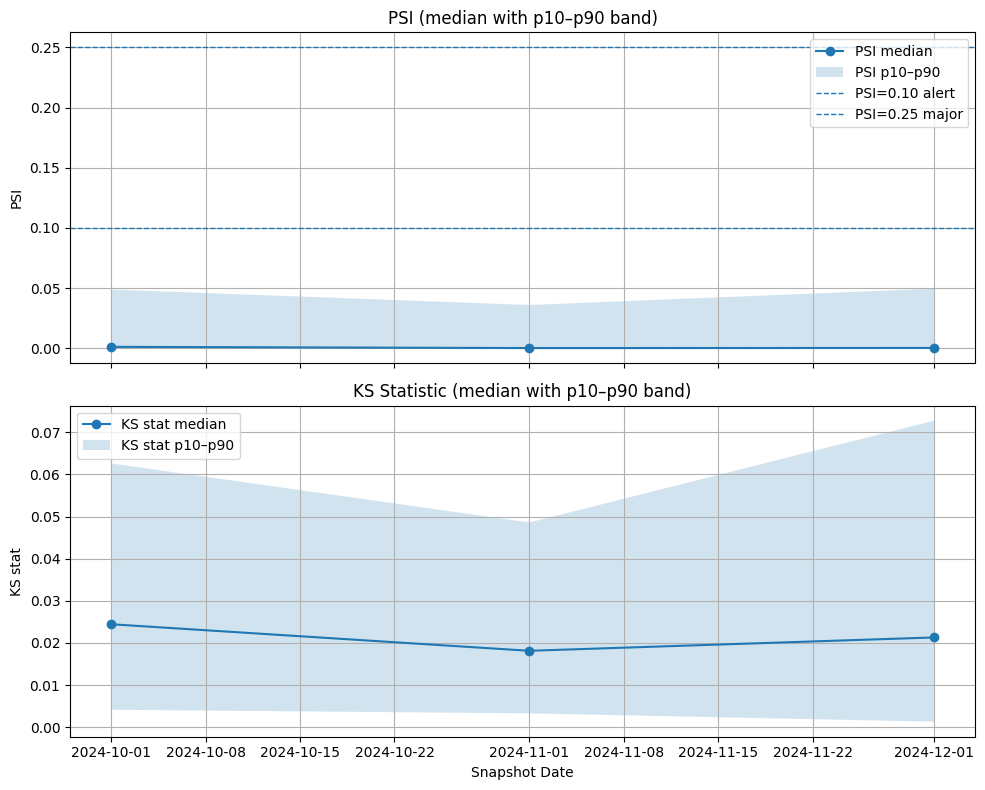

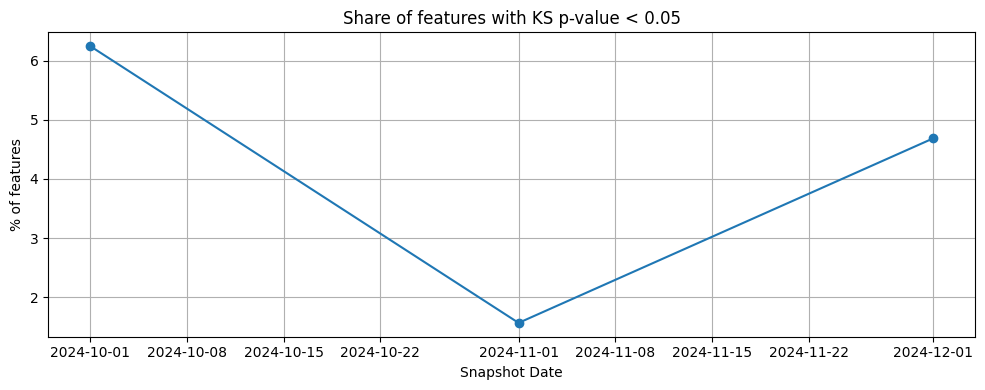

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure snapshot_date is datetime and the metrics exist
monitor_df["snapshot_date"] = pd.to_datetime(monitor_df["snapshot_date"])

# ---- per-snapshot aggregates across features ----
def p(q):
    return lambda s: s.quantile(q)

summary = (
    monitor_df
    .groupby("snapshot_date")
    .agg(
        psi_med   = ("psi", "median"),
        psi_p10   = ("psi", p(0.10)),
        psi_p90   = ("psi", p(0.90)),
        ks_med    = ("ks_stat", "median"),
        ks_p10    = ("ks_stat", p(0.10)),
        ks_p90    = ("ks_stat", p(0.90)),
        # alert counters
        psi_alert = ("psi",  lambda s: (s > 0.10).sum()),
        psi_major = ("psi",  lambda s: (s > 0.25).sum()),
        ks_p_lt05 = ("ks_pvalue", lambda s: (s < 0.05).mean()*100.0),  # %
        n_feats   = ("psi", "size")
    )
    .reset_index()
)

# ---- 1) Median + band plots ----
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# PSI
ax = axes[0]
ax.plot(summary["snapshot_date"], summary["psi_med"], marker="o", label="PSI median")
ax.fill_between(summary["snapshot_date"], summary["psi_p10"], summary["psi_p90"],
                alpha=0.2, label="PSI p10–p90")
ax.axhline(0.10, ls="--", lw=1, label="PSI=0.10 alert")
ax.axhline(0.25, ls="--", lw=1, label="PSI=0.25 major")
ax.set_title("PSI (median with p10–p90 band)")
ax.set_ylabel("PSI")
ax.grid(True)
ax.legend()

# KS stat
ax = axes[1]
ax.plot(summary["snapshot_date"], summary["ks_med"], marker="o", label="KS stat median")
ax.fill_between(summary["snapshot_date"], summary["ks_p10"], summary["ks_p90"],
                alpha=0.2, label="KS stat p10–p90")
ax.set_title("KS Statistic (median with p10–p90 band)")
ax.set_ylabel("KS stat")
ax.grid(True)
ax.legend()

axes[-1].set_xlabel("Snapshot Date")
plt.tight_layout()
plt.show()

# ---- 2) KS p-value share < 0.05 (line) ----
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(summary["snapshot_date"], summary["ks_p_lt05"], marker="o")
ax.set_title("Share of features with KS p-value < 0.05")
ax.set_ylabel("% of features")
ax.set_xlabel("Snapshot Date")
ax.grid(True)
plt.tight_layout()
plt.show()